# Operator Breakdown Analysis (Jetson): Mamba vs. Mamba2

This notebook profiles and visualizes the **GPU kernel time breakdown** of two SSM (State Space Model) architectures across increasing sequence lengths during the **prefill phase**, running on **NVIDIA Jetson AGX Orin**:

| Model | Architecture | Size |
|-------|-------------|------|
| Mamba-130m | SSM (Mamba-1) | ~130M |
| Mamba2-130m | SSM (Mamba-2) | ~130M |

Execution time is decomposed into the following operator categories:

| Category | Description |
|----------|-------------|
| **GEMM** | General Matrix Multiplications (linear projections, convolutions) |
| **SSM_Scan** | State space model recurrence scan (selective scan kernel) |
| **activation** | Activation functions (SiLU, GeLU, etc.) |
| **arithmetic** | Element-wise and reduction ops (add, mul, exp, sum, …) |
| **memory** | Data movement ops (reshape, permute, cat, copy, …) |
| **nomralization** | Layer norm and RMS norm |
| **embedding** | Token embedding lookup |
| **logit_computation** | Softmax for output logits |
| **pooling / interpolation / roi / other** | Miscellaneous ops |

Profiling data is read from `../../profile_data_jetson/` and figures are produced for both individual model breakdowns and a side-by-side Mamba vs. Mamba2 comparison.

In [1]:
import os
import pandas as pd
import matplotlib
from matplotlib import pyplot as plot

gemm_file = "gemm.csv"
non_gemm_file = "non_gemm.csv"
ssm_scan_file = "ssm_scan.csv"

color_scheme = {"GEMM":'#4C443C' , "NonGEMM":'#DEB841', "SSM_Scan":"#E48D9C", "nomralization":"#DEB841", "activation":"#769FB6", "arithmetic":"#D16666", "interpolation":"#999AC6", "memory":"#55917F",  "other":"#32373B", "pooling":"#BDBBB6", "embedding":"#83D628", "logit_computation":"#254E70", "roi":"#FAE8EB", }


color_scheme_haocheng = {"GEMM":'#7A9E9F' , "gemm":'#7A9E9F' ,"NonGEMM":'#DEB841', "nomralization":"#E97C3E", "activation":"#F1F0CC", "arithmetic":"#1D6B8B", "interpolation":"#373F51", "memory":"#373F51",  "other":"#373F51", "pooling":"#373F51", "embedding":"#373F51", "logit_computation":"#E43F6F", "roi":"#373F51", "attention":"#FAE8EB" }



gemm_ops = ["aten::mm", "aten::matmul", "aten::bmm", "aten::linear", "aten::addmm", "aten::addbmm", "aten::baddbmm", "aten::mv",    "aten::dot",
    "aten::ger", "aten::matmul.out", "aten::scaled_dot_product_attention",
    "aten::conv1d", "aten::conv2d", "aten::conv3d", "aten::conv_tbc",
    "aten::conv_transpose1d", "aten::conv_transpose2d", "aten::conv_transpose3d",
    "aten::slow_conv3d", "aten::slow_conv_dilated2d", "aten::slow_conv_dilated3d", "aten::slow_conv_transpose2d", "aten::slow_conv_transpose3d",
    "aten::thnn_conv2d","aten::thnn_conv_depthwise2d","aten::scaled_dot_product_attention", "aten::linear",'wqlinearmmfunction',"conv1d", "aten::einsum"]

attention_ops = [i for i in gemm_ops if "attention" in i]

gemm_ops_no_attn = [i for i in gemm_ops if not (i in attention_ops)]


non_gemm = ['NonGEMM']
act = ['aten::silu', 'aten::gelu', 'aten::sigmoid', 'aten::relu', 'aten::relu_', 'newgeluactivation_prof', 'triton_poi_fused_mul_silu_8', 'aten::softplus', ]
logit_computation = ['aten::softmax',]
norm = ['aten::layer_norm', 'layernormfn', 'aten::group_norm', 'aten::batch_norm', 'llamarmsnorm_prof', "detrfrozenbatchnorm2d_prof", "mixtralrmsnorm_prof", "triton_red_fused__to_copy_add_embedding_mean_mul_pow_rsqrt_0", 'triton_red_fused__to_copy_add_mean_mul_pow_rsqrt_7', 'triton_red_fused__to_copy_add_mean_mul_pow_rsqrt_9', 'triton_red_fused__to_copy_add_mean_mul_pow_rsqrt_10',  'zamba2rmsnorm_prof', 'zamba2rmsnormgated_prof', 'qwen2rmsnorm_prof', 'mambarmsnorm_prof', 'hymbarmsnorm_prof']

roi = ['torchvision::roi_align', 'torchvision::nms', ]
arith = [ 'aten::rsub','aten::add', 'aten::add_', 'aten::div', 'aten::mul', 'aten::floor', 'aten::neg',  'aten::mul_', 'aten::gt', 'aten::sub','aten::ge', 'aten::lt', 'aten::le', 'aten::eq', 'aten::ne', 'aten::bitwise_not',  'aten::__and__', 'aten::is_nonzero', 'aten::any','aten::clamp', 'aten::all', 'aten::pow', 'aten::sin', 'aten::cos', 'aten::rsqrt', 'aten::sqrt', 'aten::log2', 'aten::exp', 'aten::max', 'aten::min', 'aten::cumsum', "aten::mean", "aten::div_", "aten::index_add_", 'aten::__or__', "aten::argmax", 'aten::exponential_', 'aten::sum', 'aten::bitwise_and',  'triton_red_fused_add_all_eq_masked_fill_1', 'triton_poi_fused_add_cat_clone_mul_4', 'triton_poi_fused_add_all_bitwise_not_constant_pad_nd_eq_masked_fill_mul_6',  ]

arith_lin_elmt_wise = [ 'aten::add', 'aten::add_', 'aten::div', 'aten::mul', 'aten::floor', 'aten::neg',  'aten::mul_', 'aten::gt', 'aten::sub','aten::ge', 'aten::lt', 'aten::le', 'aten::eq', 'aten::ne', 'aten::bitwise_not',  'aten::__and__', 'aten::is_nonzero', 'aten::clamp', 'aten::all', ]

arith_non_lin_elmt_wise = ['aten::pow', 'aten::sin', 'aten::cos', 'aten::rsqrt', 'aten::sqrt', 'aten::log2', 'aten::exp',]

arith_lin_red = ['aten::max', 'aten::min', 'aten::cumsum',   ]

pooling = ['aten::adaptive_avg_pool1d','aten::max_pool2d', 'aten::adaptive_avg_pool2d',  ]

interpolation = ['aten::upsample_nearest2d', 'aten::upsample_bilinear2d',  ]

embedding = ['aten::embedding',]

mem = ['aten::slice', 'aten::chunk', 'aten::view', 'aten::permute', 'aten::transpose', 'aten::t', 'aten::reshape',  'aten::flatten', 'aten::pad', 'aten::contiguous',  'aten::index', 'aten::unsqueeze', 'aten::to', 'aten::cat', 'aten::copy_', 'aten::empty', 'aten::expand', 'aten::new_empty', 'aten::new_zeros', 'aten::where',  'aten::unbind',  'aten::select', 'aten::new_full', 'aten::masked_fill', 'aten::ones', 'aten::fill_', 'aten::full', 'aten::repeat', 'aten::stack',  'aten::arange',  'aten::type_as', 'aten::_unique2', 'aten::index_put_', 'aten::zeros', 'aten::zero_',   'aten::zeros_like', 'aten::expand_as', 'aten::full_like',  'aten::detach',   'aten::detach_', 'aten::split_with_sizes', 'aten::split', 'aten::tensor_split', "aten::one_hot", "aten::scatter", "aten::new_ones", 'aten::squeeze', 'aten::clone', 'aten::masked_fill_', 'aten::ones_like', 'aten::empty_like', 'aten::resize_' , 'triton_poi_fused__to_copy_2', 'triton_poi_fused__to_copy_3', 'triton_poi_fused_clone_5',  'triton_poi_fused__to_copy_11', 'aten::_unsafe_view', 'aten::item', 'aten::alias', 'aten::concatenate', ]

other = ['aten::dropout', 'aten::lift_fresh', 'aten::meshgrid', 'aten::topk', 'aten::sort', 'aten::argsort','torchdynamo cache lookup','torch-compiled region','aten::_assert_async', 'aten::triu',]

non_gemm_ops = act + logit_computation + norm + roi + arith + pooling + interpolation + embedding + mem + other
non_gemm_ops_dict = {'activation':act, "logit_computation":logit_computation,
                     'nomralization':norm, 'arithmetic':arith, "pooling":pooling,
                     'interpolation':interpolation, 'embedding': embedding,
                     'memory':mem, 'roi':roi, 'other':other,}

gemm_ops_dict = {
    "gemm":gemm_ops_no_attn, 
    "attention":attention_ops,
}

ops_dict = {
    "gemm":gemm_ops_no_attn, 
    "attention":attention_ops,
    'activation':act, "logit_computation":logit_computation,
    'nomralization':norm, 'arithmetic':arith, "pooling":pooling,
    'interpolation':interpolation, 'embedding': embedding,
    'memory':mem, 'roi':roi, 'other':other,

}

batch_sizes = [1]#[1,2,4,8]#[1]#[1,8]#

## utils##
def filter_dataframes(df, list):
    # Filter DataFrame rows where "name" is in the current list
    df_ = df[df['name'].isin(list)]
    return df_

def sum_df_append (filtered_df, name):
    summed_row = filtered_df.drop(columns=["name"]).sum()
    # Add a new row with the sum and a custom 'name' value
    summed_row["name"] = name
    df = pd.concat([filtered_df, pd.DataFrame([summed_row])], ignore_index=True)
    # summary_row = filtered_df.drop(columns=["name"], errors='ignore').sum(numeric_only=True)
    # summary_row["name"] = name  # Add the list's name
    # filtered_df = pd.concat([filtered_df, summary_row.to_frame()])
    return df, summed_row.to_frame().T


def check_new_non_gemm (unique_non_gemm): 
    new_non_gemm = []

    for op in unique_non_gemm: 
        if not (op in non_gemm_ops): 
            new_non_gemm.append(op)
    print (f"New Non-GEMM Operators:") 
    print (new_non_gemm)

def summarize_non_gemm(prof_dir:str = "./non-gemm-out",out_dir = None):
    direct = get_directories(prof_dir)
    for dir in direct:
        data_file = f"{prof_dir}/{dir}/{non_gemm_file}"
        if not (os.path.exists(data_file)):
            continue
        df_nongemm = pd.read_csv(data_file)
        unique_nongemm = df_nongemm['name'].unique().tolist()
        check_new_non_gemm(unique_nongemm)
        df_summary = pd.read_csv(f"{prof_dir}/{dir}/{dir}.csv")
        df_gng = df_summary[df_summary['name'].isin(['GEMM', 'NonGEMM'])]
        df_gng_ssm = df_summary[df_summary['name'].isin(['GEMM', 'NonGEMM', 'SSM_Scan'])]
        df_summary = df_summary[df_summary['name'].isin(['GEMM', 'SSM_Scan'])]
        for group, list_ in non_gemm_ops_dict.items():
            df_ = filter_dataframes(df_nongemm, list_)
            df_, summary_row = sum_df_append(df_, group)
            df_summary = pd.concat([df_summary, summary_row], ignore_index=True).drop(columns = ['Unnamed: 0'])
            #print (df_)
            #break
            df_.to_csv(f"{prof_dir}/{dir}/{group}.csv")
        #break
        df_summary.to_csv(f"{prof_dir}/{dir}/summary_{dir}.csv")
        df_gng.to_csv(f"{prof_dir}/{dir}/gng_{dir}.csv")
        df_gng_ssm.to_csv(f"{prof_dir}/{dir}/gng_ssm_{dir}.csv")

        df_summary_transpose = df_summary[["name", "total_time (us)"]]#.set_index ('name')#[df_summary['name'] == 'total_time (us)']
        # df_summary_transpose_cpu = df_summary[["name", "cpu_time (us)"]]#.set_index ('name')#[df_summary['name'] == 'total_time (us)']
        df_gng_transpose = df_gng[["name", "total_time (us)"]]#.set_index ('name')#[df_summary['name'] == 'total_time (us)']
        df_gng_ssm_transpose = df_gng_ssm[["name", "total_time (us)"]]

        df_ = df_summary_transpose
        # df_ = df_summary_transpose_cpu
        sum_ = df_['total_time (us)'].sum()
        # sum_ = df_['cpu_time (us)'].sum()
        df_['pct'] = (df_['total_time (us)'] / sum_) * 100
        # df_['pct'] = (df_['cpu_time (us)'] / sum_) * 100
        df_.to_csv(f'{prof_dir}/{dir}/pct_{dir}.csv')

        df_ = df_gng_transpose
        sum_ = df_['total_time (us)'].sum()
        df_['pct'] = (df_['total_time (us)'] / sum_) * 100
        df_.to_csv(f'{prof_dir}/{dir}/gng_pct_{dir}.csv')

        df_ = df_gng_ssm_transpose
        sum_ = df_['total_time (us)'].sum()
        df_['pct'] = (df_['total_time (us)'] / sum_) * 100
        df_.to_csv(f'{prof_dir}/{dir}/gng_ssm_pct_{dir}.csv')


def get_directories(path: str= "./non-gemm-out"):
    entries = os.listdir(path)
    # Filter only directories
    directories = [entry for entry in entries if os.path.isdir(os.path.join(path, entry))]
    return directories


## Configuration and Setup

Define operator category lists, color schemes, and utility functions used throughout the notebook.

- **`gemm_ops` / `non_gemm_ops_dict`** — enumerate which PyTorch/Triton kernel names belong to each category.
- **`summarize_non_gemm`** — reads raw per-directory profiling CSVs, aggregates kernel times into the categories above, computes percentage breakdowns, and writes summary CSVs back to each profile directory.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys

# Define the models and their sequence lengths
mamba_models = [
    'mamba-130m',
    'mamba2-130m',
]

seq_lengths = {
    'mamba-130m': [256, 512, 1024, 2048, 4096, 8192, 16384, 32768],
    'mamba2-130m': [256, 512, 1024, 2048, 4096, 8192, 16384, 32768],
}

# Directory where the profiling data is stored
prof_dir = '../../profile_data_jetson'

# Make sure non-GEMM operations are summarized
summarize_non_gemm(prof_dir=prof_dir)

New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']


/tmp/ipykernel_840298/1363827789.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['pct'] = (df_['total_time (us)'] / sum_) * 100
/tmp/ipykernel_840298/1363827789.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['pct'] = (df_['total_time (us)'] / sum_) * 100
/tmp/ipykernel_840298/1363827789.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']
New Non-GEMM Operators:
['NonGEMM', 'Inference']


/tmp/ipykernel_840298/1363827789.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['pct'] = (df_['total_time (us)'] / sum_) * 100
/tmp/ipykernel_840298/1363827789.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['pct'] = (df_['total_time (us)'] / sum_) * 100
/tmp/ipykernel_840298/1363827789.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

## Data Loading Helper

Define `extract_model_seq_data`, which reads the pre-computed percentage breakdown CSV (`pct_<model>_<device>_<bs>_<seqlen>.csv`) for every sequence length and returns a dict mapping `seq_len → DataFrame`.

Sequence lengths evaluated on Jetson AGX Orin range from **256 to 32,768** tokens.

In [3]:
# Function to extract data for each model and sequence length
def extract_model_seq_data(model, device='cuda', batch_size=1):
    model_data = {}
    
    for seq_len in seq_lengths[model]:
        filename = f"{prof_dir}/{model}_{device}_{batch_size}_{seq_len}/pct_{model}_{device}_{batch_size}_{seq_len}.csv"
        
        if not os.path.exists(filename):
            print(f"File {filename} does not exist. Skipping...")
            continue
            
        df = pd.read_csv(filename)
        model_data[seq_len] = df
    
    return model_data

## Load Profiling Data

Call `extract_model_seq_data` for both Mamba-130m and Mamba2-130m. Available sequence lengths are printed to confirm which data directories were found under `../../profile_data_jetson/`.

In [4]:
# Extract data for both models
mamba_data = extract_model_seq_data('mamba-130m')
mamba2_data = extract_model_seq_data('mamba2-130m')

# Check if we have data
print(f"mamba-130m sequence lengths: {list(mamba_data.keys())}")
print(f"mamba2-130m sequence lengths: {list(mamba2_data.keys())}")

mamba-130m sequence lengths: [256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
mamba2-130m sequence lengths: [256, 512, 1024, 2048, 4096, 8192, 16384, 32768]


## Build Breakdown DataFrames

`create_breakdown_df` pivots the per-sequence-length data into a single DataFrame where rows are operator categories and columns are sequence lengths, making it easy to compare how the kernel mix shifts as context grows.

In [5]:
# Function to create dataframe with percentage breakdown for each sequence length
def create_breakdown_df(model_data):
    seq_breakdown = {}
    
    for seq_len, df in model_data.items():
        # Create a dictionary of op_name -> percentage
        breakdown = dict(zip(df['name'], df['pct']))
        seq_breakdown[seq_len] = breakdown
    
    # Convert to DataFrame
    breakdown_df = pd.DataFrame(seq_breakdown)
    return breakdown_df

## Compute and Save Breakdowns

Materialize the breakdown DataFrames for both models and display them. The tables are also written to `mamba_breakdown.csv` and `mamba2_breakdown.csv` under `profile_data_jetson/` for reproducibility.

In [6]:
# Create breakdown dataframes
mamba_breakdown = create_breakdown_df(mamba_data)
mamba2_breakdown = create_breakdown_df(mamba2_data)

# Display the breakdowns
print("Mamba Breakdown:")
print(mamba_breakdown)
print("\nMamba2 Breakdown:")
print(mamba2_breakdown)

# save the breakdown dataframes to CSV files
mamba_breakdown.to_csv(f"{prof_dir}/mamba_breakdown.csv")
mamba2_breakdown.to_csv(f"{prof_dir}/mamba2_breakdown.csv")

Mamba Breakdown:
                       256        512        1024       2048       4096   \
GEMM               11.959881  16.614163  19.041704  25.510867  28.181038   
SSM_Scan           57.973288  58.368927  57.835115  55.468353  57.088539   
activation          0.000000   0.000000   0.000000   0.000000   0.000000   
logit_computation   0.000000   0.000000   0.000000   0.000000   0.000000   
nomralization      17.142022  14.626043  13.848258  11.996962   9.745393   
arithmetic          3.284643   2.666226   2.373082   1.775619   1.237138   
pooling             0.000000   0.000000   0.000000   0.000000   0.000000   
interpolation       0.000000   0.000000   0.000000   0.000000   0.000000   
embedding           0.316608   0.290706   0.283226   0.258002   0.253795   
memory              9.323558   7.433935   6.618615   4.990197   3.494097   
roi                 0.000000   0.000000   0.000000   0.000000   0.000000   
other               0.000000   0.000000   0.000000   0.000000   0.00000

## Visualization — Individual Model Breakdown

The `plot_model_breakdown` helper below creates a stacked bar chart for a single model. Operations are sorted by mean percentage so the most time-consuming categories naturally appear at the bottom of each bar. The more polished `plot_with_custom_order` variant (used for the paper figure) additionally pins **SSM_Scan** and **GEMM** at the bottom of the stack for consistent visual comparison across models.

In [7]:
# Function to plot stacked bar chart for a single model
def plot_model_breakdown(breakdown_df, model_name, color_scheme):
    # Sort the operations by overall percentage (higher percentages at the bottom of the stack)
    op_order = breakdown_df.mean(axis=1).sort_values().index.tolist()
    
    # Plot the stacked bar chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Get sequence lengths as strings for x-axis
    seq_lengths = [str(x) for x in breakdown_df.columns]
    
    # Create a bottom offset for stacking
    bottom = np.zeros(len(seq_lengths))
    
    # Plot each operation as a stacked segment
    for op in op_order:
        if op in color_scheme:
            color = color_scheme[op]
        else:
            color = color_scheme.get('other', '#32373B')
            
        values = breakdown_df.loc[op].values if op in breakdown_df.index else np.zeros(len(seq_lengths))
        ax.bar(seq_lengths, values, bottom=bottom, label=op, color=color)
        bottom += values
    
    # Set chart properties
    ax.set_title(f'{model_name} Operator Breakdown by Sequence Length', fontsize=16)
    ax.set_xlabel('Sequence Length', fontsize=11)
    ax.set_ylabel('Percentage (%)', fontsize=11)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax

### Annotated Plots (with axis labels and title)

Intermediate version with full axis labels and titles — useful for quick inspection and debugging the operator ordering.

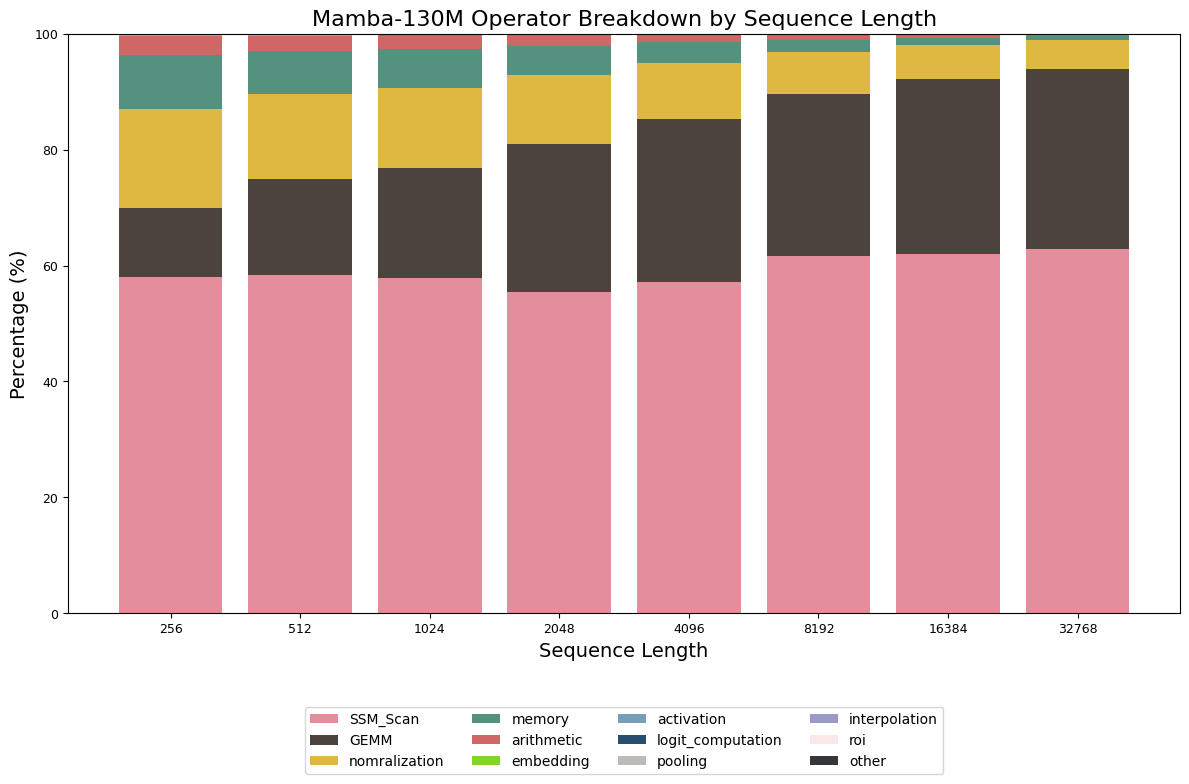

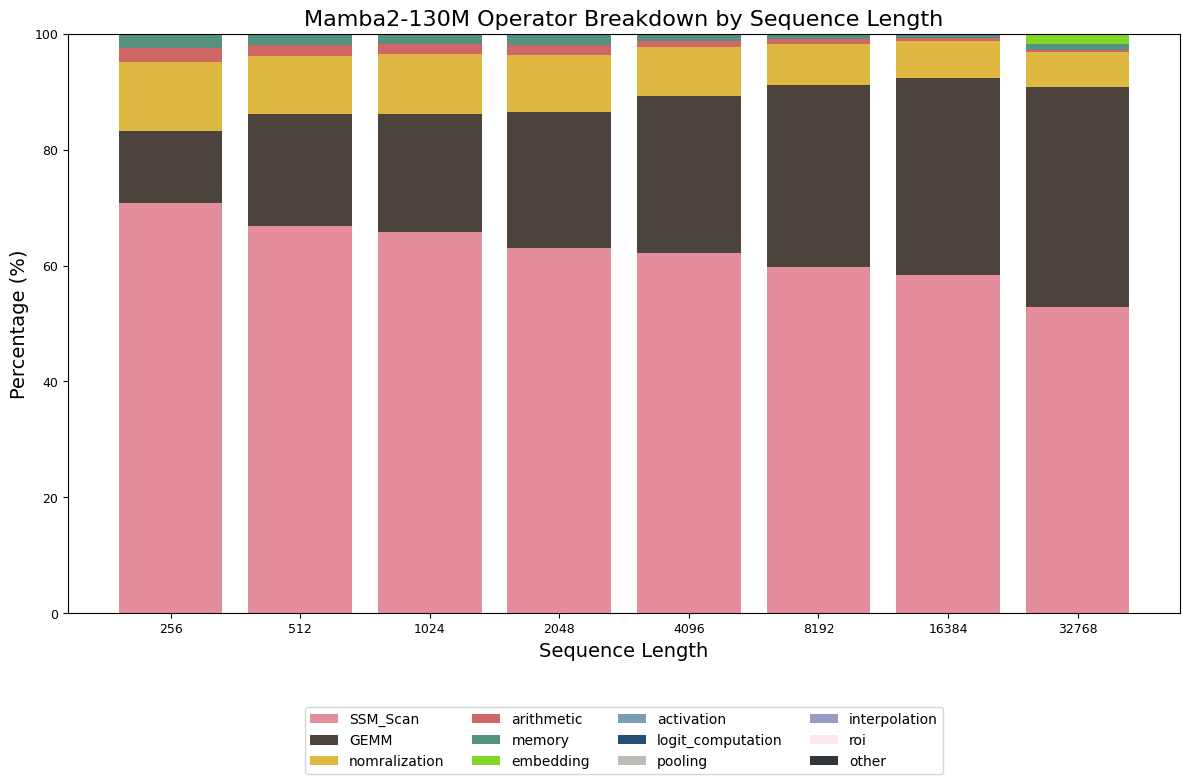

In [10]:
# Plot breakdown for mamba model with custom stacking order
# Define custom order with SSM_Scan at bottom, then GEMM, then others in descending order
def plot_with_custom_order(breakdown_df, model_name, color_scheme):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Get sequence lengths as strings for x-axis
    seq_lengths = [str(x) for x in breakdown_df.columns]
    
    # Create a copy of the dataframe for sorting
    df_copy = breakdown_df.copy()
    
    # Remove SSM_Scan and GEMM from consideration for sorting
    other_ops = [op for op in df_copy.index if op not in ['SSM_Scan', 'GEMM']]
    
    # Sort remaining operations by mean percentage (highest first)
    other_ops_sorted = sorted(other_ops, key=lambda x: df_copy.loc[x].mean(), reverse=True)
    
    # Define the final order with SSM_Scan at bottom, then GEMM, then others
    op_order = ['SSM_Scan', 'GEMM'] + other_ops_sorted
    
    # Plot bars in reverse order to get the desired stacking (first in list is at bottom)
    bottom = np.zeros(len(seq_lengths))
    
    for op in op_order:
        if op in breakdown_df.index:
            values = breakdown_df.loc[op].values
            color = color_scheme.get(op, color_scheme.get('other', '#32373B'))
            ax.bar(seq_lengths, values, bottom=bottom, label=op, color=color)
            bottom += values
    
    # Set chart properties
    ax.set_title(f'{model_name} Operator Breakdown by Sequence Length', fontsize=16)
    ax.set_xlabel('Sequence Length', fontsize=14)
    ax.set_ylabel('Percentage (%)', fontsize=14)
    
    # Make tick labels smaller
    ax.tick_params(axis='both', which='major', labelsize=9)
    
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax

# Plot breakdown for mamba model with custom order
fig_mamba, ax_mamba = plot_with_custom_order(mamba_breakdown, 'Mamba-130M', color_scheme)
plt.savefig(f"mamba_130m_jetson_breakdown.png", bbox_inches="tight", dpi=300)
plt.show()

# Plot breakdown for mamba2 model with custom order
fig_mamba2, ax_mamba2 = plot_with_custom_order(mamba2_breakdown, 'Mamba2-130M', color_scheme)
plt.savefig(f"mamba2_130m_jetson_breakdown.png", bbox_inches="tight", dpi=300)
plt.show()

### Clean Plots (paper-ready, no axis labels)

Stripped-down version that removes all axis labels, tick labels, and the legend — intended to be embedded as a compact panel in the paper figure, where annotations are supplied by the figure caption or a surrounding layout.

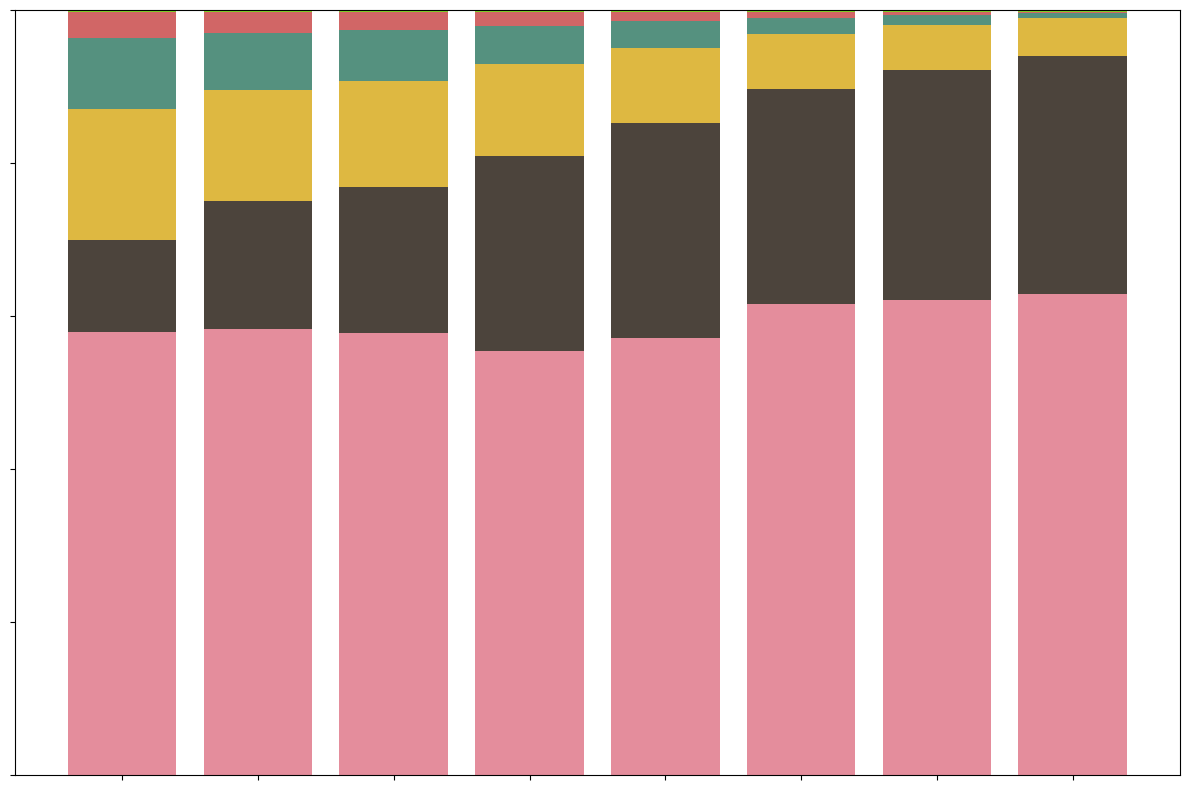

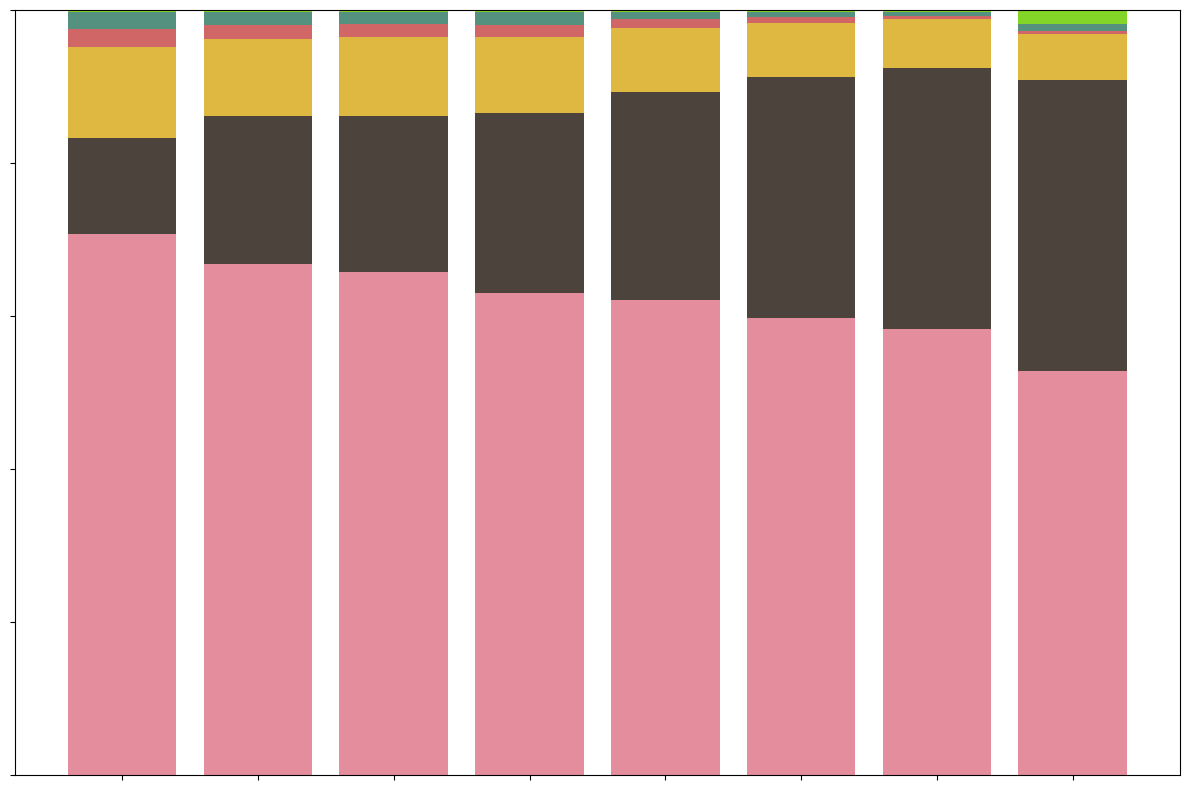

In [9]:
# Plot breakdown for mamba model with custom stacking order
# Define custom order with SSM_Scan at bottom, then GEMM, then others in descending order
def plot_with_custom_order(breakdown_df, model_name, color_scheme):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Get sequence lengths as strings for x-axis
    seq_lengths = [str(x) for x in breakdown_df.columns]
    
    # Create a copy of the dataframe for sorting
    df_copy = breakdown_df.copy()
    
    # Remove SSM_Scan and GEMM from consideration for sorting
    other_ops = [op for op in df_copy.index if op not in ['SSM_Scan', 'GEMM']]
    
    # Sort remaining operations by mean percentage (highest first)
    other_ops_sorted = sorted(other_ops, key=lambda x: df_copy.loc[x].mean(), reverse=True)
    
    # Define the final order with SSM_Scan at bottom, then GEMM, then others
    op_order = ['SSM_Scan', 'GEMM'] + other_ops_sorted
    
    # Plot bars in reverse order to get the desired stacking (first in list is at bottom)
    bottom = np.zeros(len(seq_lengths))
    
    for op in op_order:
        if op in breakdown_df.index:
            values = breakdown_df.loc[op].values
            color = color_scheme.get(op, color_scheme.get('other', '#32373B'))
            ax.bar(seq_lengths, values, bottom=bottom, label=op, color=color)
            bottom += values
    
    # Set chart properties
    # ax.set_title(f'{model_name} Operator Breakdown by Sequence Length', fontsize=16)
    # ax.set_xlabel('Sequence Length', fontsize=14)
    # ax.set_ylabel('Percentage (%)', fontsize=14)
    
    # Make tick labels smaller
    ax.tick_params(axis='both', which='major', labelsize=9, labelbottom=False, labelleft=False)
    
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax

# Plot breakdown for mamba model with custom order
fig_mamba, ax_mamba = plot_with_custom_order(mamba_breakdown, 'Mamba-130M', color_scheme)
# plt.savefig(f"{prof_dir}/mamba_130m_breakdown.png", bbox_inches="tight", dpi=300)
plt.show()

# Plot breakdown for mamba2 model with custom order
fig_mamba2, ax_mamba2 = plot_with_custom_order(mamba2_breakdown, 'Mamba2-130M', color_scheme)
# plt.savefig(f"{prof_dir}/mamba2_130m_breakdown.png", bbox_inches="tight", dpi=300)
plt.show()